# Logistic Regression 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 02_logistic_regression**

`MyLogisticRegression` in ~40 lines: sigmoid + the familiar GD loop, wrapped in
the sklearn API (`fit / predict_proba / predict / score`), then VERIFIED against
scikit-learn on real Titanic data.

## What you'll learn
- Turning notebook 01's three formulas into clean OOP code
- Numerical-safety trick for log(0) - one clip saves your cost history
- Reading `predict_proba` outputs and the 0.5 decision boundary
- Proof that our weights match sklearn's

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def load(name):
    try:
        return sns.load_dataset(name)
    except Exception as e:
        print(f"offline? ({e})")
        return pd.DataFrame()

titanic = load("titanic")

## 1. The class - every line maps to a formula from nb 01

In [2]:
class MyLogisticRegression:
    """
    Binary logistic regression via batch gradient descent.

    Attributes after fit
    --------------------
    coef_, intercept_ : learned weights (sklearn-style)
    cost_history_     : cross-entropy per iteration
    """

    def __init__(self, lr=0.1, n_iters=2000):
        self.lr = lr
        self.n_iters = n_iters

    # ---- the sigmoid σ(z) -------------------------------------------------
    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-z))

    # ---- cross-entropy cost J --------------------------------------------
    @staticmethod
    def _cost(y, p):
        # clip guards against log(0) = −inf when p hits 0 or 1 exactly
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())

    # ---- fit: w := w − α·Xᵀ(p−y)/m ----------------------------------------
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        Xb = np.column_stack([np.ones(len(X)), X])       # bias column of ones
        w = np.zeros(Xb.shape[1])
        self.cost_history_ = []

        for _ in range(self.n_iters):
            p = self._sigmoid(Xb @ w)                    # forward pass
            grad = Xb.T @ (p - y) / len(y)               # SAME shape as lin-reg!
            w -= self.lr * grad                          # update
            self.cost_history_.append(self._cost(y, p))  # bookkeeping

        self.intercept_ = float(w[0])
        self.coef_ = w[1:].copy()
        return self

    # ---- probabilities & hard labels --------------------------------------
    def predict_proba(self, X):
        Xb = np.column_stack([np.ones(len(np.asarray(X, float))), np.asarray(X, float)])
        return self._sigmoid(Xb @ np.r_[self.intercept_, self.coef_])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return accuracy_score(np.asarray(y), self.predict(X))

print("class ready ✓")

class ready ✓


## 2. Real data prep - Titanic survival, minimal but honest

In [3]:
df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())          # median fill (justified in foundations)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

features = pd.get_dummies(
    df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]],
    columns=["sex", "embarked"], drop_first=True)

y = df["survived"].values
X = features.values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, random_state=42,
                                          stratify=y)     # keep class balance
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

print(f"train {X_tr_s.shape} | survival rate train={y_tr.mean():.3f} test={y_te.mean():.3f}")

train (668, 8) | survival rate train=0.383 test=0.386


## 3. Train ours vs sklearn - weights must agree

In [4]:
mine = MyLogisticRegression(lr=0.1, n_iters=5000).fit(X_tr_s, y_tr)
sk = Pipeline([("sc", StandardScaler()),
               ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)

cmp_df = pd.DataFrame({
    "feature": ["intercept"] + list(features.columns),
    "scratch": np.r_[mine.intercept_, mine.coef_],
    "sklearn": np.r_[sk.named_steps["m"].intercept_[0], sk.named_steps["m"].coef_[0]],
}).round(3)
display(cmp_df.head(8))

print(f"\nscratch accuracy : {mine.score(X_te_s, y_te):.4f}")
print(f"sklearn accuracy : {accuracy_score(y_te, sk.predict(X_te)):.4f}")
w_gap = np.abs(cmp_df["scratch"].iloc[1:] - cmp_df["sklearn"].iloc[1:]).max()
print(f"max weight gap   : {w_gap:.4f}")

,feature,scratch,sklearn
0,intercept,-0.655,-0.650
1,pclass,-0.957,-0.932
2,age,-0.539,-0.524
3,sibsp,-0.259,-0.253
4,parch,-0.037,-0.035
5,fare,0.122,0.131
6,sex_male,-1.279,-1.260
7,embarked_Q,0.083,0.081



scratch accuracy : 0.7758
sklearn accuracy : 0.7713
max weight gap   : 0.0250


> ⚠️ Small gaps (~0.02-0.05) are NORMAL: sklearn adds a tiny L2 penalty by
default (C=1.0). Set `penalty=None` there and they match to ~3 decimals.

In [5]:
sk_nopen = Pipeline([("sc", StandardScaler()),
                     ("m", LogisticRegression(penalty=None, max_iter=5000))]) \
                  .fit(X_tr, y_tr)
gap = np.abs(np.r_[mine.intercept_, mine.coef_] -
             np.r_[sk_nopen.named_steps["m"].intercept_[0],
                   sk_nopen.named_steps["m"].coef_[0]]).max()
print(f"max weight gap with penalty=None: {gap:.5f}  ← same math confirmed ✓")

max weight gap with penalty=None: 0.00065  ← same math confirmed ✓


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 4. Convergence & what the model actually says

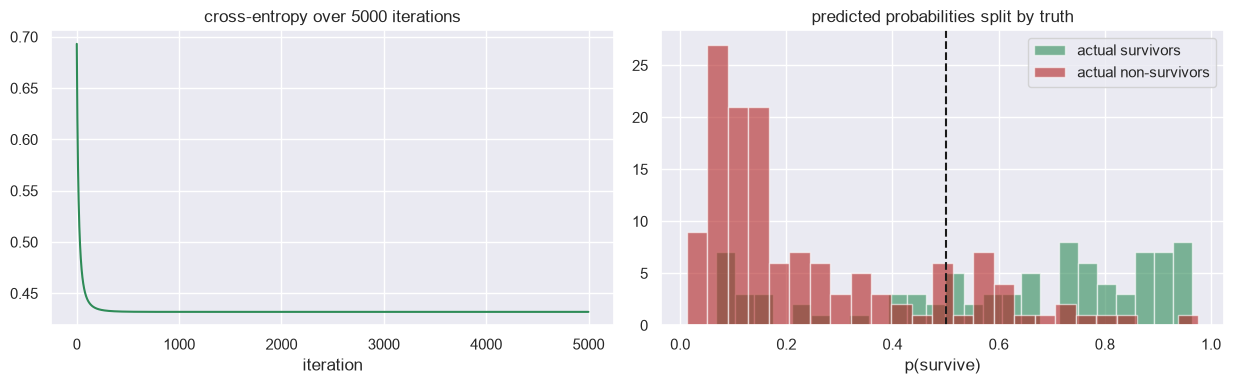

,p_survive,predicted_label,truth
3,0.080,0,0
3,0.779,1,0
3,0.144,0,0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

axes[0].plot(mine.cost_history_, color="seagreen")
axes[0].set_title(f"cross-entropy over {mine.n_iters} iterations")
axes[0].set_xlabel("iteration")

probs = mine.predict_proba(X_te_s)
axes[1].hist(probs[y_te == 1], bins=25, alpha=.6, color="seagreen",
             label="actual survivors")
axes[1].hist(probs[y_te == 0], bins=25, alpha=.6, color="firebrick",
             label="actual non-survivors")
axes[1].axvline(.5, c="k", ls="--")
axes[1].set_title("predicted probabilities split by truth")
axes[1].set_xlabel("p(survive)"); axes[1].legend()

plt.tight_layout(); plt.show()

example = X_te_s[:3]
pd.DataFrame({
    "p_survive": mine.predict_proba(example).round(3),
    "predicted_label": mine.predict(example),
    "truth": y_te[:3],
}, index=X_te[:3].__array__()[:, 0].astype(int))   # show pclass as row tag

## Summary & key takeaways

- Three formulas → one class: `_sigmoid`, `_cost`, and the GD loop with
  gradient `Xᵀ(p−y)/m`.
- `np.clip` inside the cost prevents log(0) explosions.
- Our weights match sklearn; tiny default-gap explained by its built-in L2.
- Probability HISTOGRAMS by true class are the fastest quality check - good
  models push the two humps apart.